Import relevant libraries

In [250]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt # Visualization
import seaborn as sns #Visualization


Import and display data

In [251]:
file_path = '../Dataset/combined_data_3-2022_3-2023.csv'

df = pd.read_csv(file_path)

display(df)

selected_row = df.iloc[1490]

print(selected_row)

C:\Users\harikan\AppData\Local\Temp\1\ipykernel_7976\2600100106.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


,Date,Time,kW,Nantum,Billing Period,Season,kW Pricing,Facilities Demand Charge,Altimeter reading,DP Temp (F),DB Temp (F),Date Time,Year,Month,Billing Period Label,Day,Hour,Unnamed: 17
0,3/23/2022,12:00:00 AM,161.100,-,Mar,Winter,$0.60,$2.68,30.27,24.00,61,3/23/2022 0:00,2022,3,Mar,23,-,0
1,3/23/2022,12:15:00 AM,162.000,-,Mar,Winter,$0.60,$2.68,30.27,24.00,61,3/23/2022 0:15,2022,3,Mar,23,-,0
2,3/23/2022,12:30:00 AM,156.600,-,Mar,Winter,$0.60,$2.68,30.27,24.00,61,3/23/2022 0:30,2022,3,Mar,23,-,0
3,3/23/2022,12:45:00 AM,161.552,-,Mar,Winter,$0.60,$2.68,30.27,24.00,61,3/23/2022 0:45,2022,3,Mar,23,-,0
4,3/23/2022,1:00:00 AM,159.752,-,Mar,Winter,$0.60,$2.68,30.26,23.00,58,3/23/2022 1:00,2022,3,Mar,23,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35034,3/22/2023,10:45:00 PM,117.448,Enable,Feb,Winter,$0.60,$2.68,30.03,34.0,49,3/22/2023 22:45,2023,3,Feb,22,22,Enable
35035,3/22/2023,11:00:00 PM,115.200,Enable,Feb,Winter,$0.60,$2.68,30.03,34.0,50,3/22/2023 23:00,2023,3,Feb,22,23,Enable
35036,3/22/2023,11:15:00 PM,118.348,Enable,Feb,Winter,$0.60,$2.68,30.03,34.0,50,3/22/2023 23:15,2023,3,Feb,22,23,Enable
35037,3/22/2023,11:30:00 PM,116.100,Enable,Feb,Winter,$0.60,$2.68,30.03,34.0,50,3/22/2023 23:30,2023,3,Feb,22,23,Enable


Date                              4/7/2022
Time                           12:30:00 PM
kW                                   306.9
Nantum                                -   
Billing Period                        Mar 
Season                             Winter 
kW Pricing                          $0.60 
Facilities Demand Charge            $2.68 
Altimeter reading                    30.25
DP Temp (F)                          -4.00
DB Temp (F)                             80
Date Time                   4/7/2022 12:30
Year                                  2022
Month                                    4
Billing Period Label                  Mar 
Day                                      7
Hour                                    12
Unnamed: 17                              0
Name: 1490, dtype: object


Drop irrelevant features (Billing Period, kW Pricing, Facilities Demand Charge, Date Time, Year, Billing Period Label, Unnamed: 17)

In [252]:
# specify the columns
columns_to_drop = ['Date', 'Time', 'Billing Period', 'kW Pricing', 'Facilities Demand Charge', 'Year', 'Month', 'Day', 'Hour', 
'Billing Period Label', 'Unnamed: 17']

# Drop the specified columns
df.drop(columns=columns_to_drop, inplace=True)


In [253]:
display(df)


,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Date Time
0,161.100,-,Winter,30.27,24.00,61,3/23/2022 0:00
1,162.000,-,Winter,30.27,24.00,61,3/23/2022 0:15
2,156.600,-,Winter,30.27,24.00,61,3/23/2022 0:30
3,161.552,-,Winter,30.27,24.00,61,3/23/2022 0:45
4,159.752,-,Winter,30.26,23.00,58,3/23/2022 1:00
...,...,...,...,...,...,...,...
35034,117.448,Enable,Winter,30.03,34.0,49,3/22/2023 22:45
35035,115.200,Enable,Winter,30.03,34.0,50,3/22/2023 23:00
35036,118.348,Enable,Winter,30.03,34.0,50,3/22/2023 23:15
35037,116.100,Enable,Winter,30.03,34.0,50,3/22/2023 23:30


Add heat_day and cool_day columns. These columns represent if the building is going to use electricity for either heating or cooling purposes.

In [254]:
# Calculate CDD & HDD
heat_base = 65
cool_base = 57
time_int  = 1/24/4 #15min
df['Heat_day'] = (heat_base - df['DB Temp (F)'])*time_int
df['Cool_day'] = (df['DB Temp (F)'] - cool_base)*time_int
df.loc[df['Heat_day'] <= 0, 'Heat_day' ] = 0
df.loc[df['Cool_day'] <= 0, 'Cool_day' ] = 0

# # Drop index
# df['dt'] = df.index
# df.reset_index(inplace=True,drop=True)
display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Date Time,Heat_day,Cool_day
0,161.100,-,Winter,30.27,24.00,61,3/23/2022 0:00,0.041667,0.041667
1,162.000,-,Winter,30.27,24.00,61,3/23/2022 0:15,0.041667,0.041667
2,156.600,-,Winter,30.27,24.00,61,3/23/2022 0:30,0.041667,0.041667
3,161.552,-,Winter,30.27,24.00,61,3/23/2022 0:45,0.041667,0.041667
4,159.752,-,Winter,30.26,23.00,58,3/23/2022 1:00,0.072917,0.010417
...,...,...,...,...,...,...,...,...,...
35034,117.448,Enable,Winter,30.03,34.0,49,3/22/2023 22:45,0.166667,0.000000
35035,115.200,Enable,Winter,30.03,34.0,50,3/22/2023 23:00,0.156250,0.000000
35036,118.348,Enable,Winter,30.03,34.0,50,3/22/2023 23:15,0.156250,0.000000
35037,116.100,Enable,Winter,30.03,34.0,50,3/22/2023 23:30,0.156250,0.000000


Change Nantum to binary values. 0 if not enabled, 1 if enabled.
Change Season to binary values. 0 if Winter, 1 if Summer.
Replace missing values with 0 in DP Temp (F) and create a plot to see if there is any empty cell in the dataset

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Date Time,Heat_day,Cool_day
0,161.100,0,0,30.27,24.00,61,3/23/2022 0:00,0.041667,0.041667
1,162.000,0,0,30.27,24.00,61,3/23/2022 0:15,0.041667,0.041667
2,156.600,0,0,30.27,24.00,61,3/23/2022 0:30,0.041667,0.041667
3,161.552,0,0,30.27,24.00,61,3/23/2022 0:45,0.041667,0.041667
4,159.752,0,0,30.26,23.00,58,3/23/2022 1:00,0.072917,0.010417
...,...,...,...,...,...,...,...,...,...
35034,117.448,1,0,30.03,34.0,49,3/22/2023 22:45,0.166667,0.000000
35035,115.200,1,0,30.03,34.0,50,3/22/2023 23:00,0.156250,0.000000
35036,118.348,1,0,30.03,34.0,50,3/22/2023 23:15,0.156250,0.000000
35037,116.100,1,0,30.03,34.0,50,3/22/2023 23:30,0.156250,0.000000


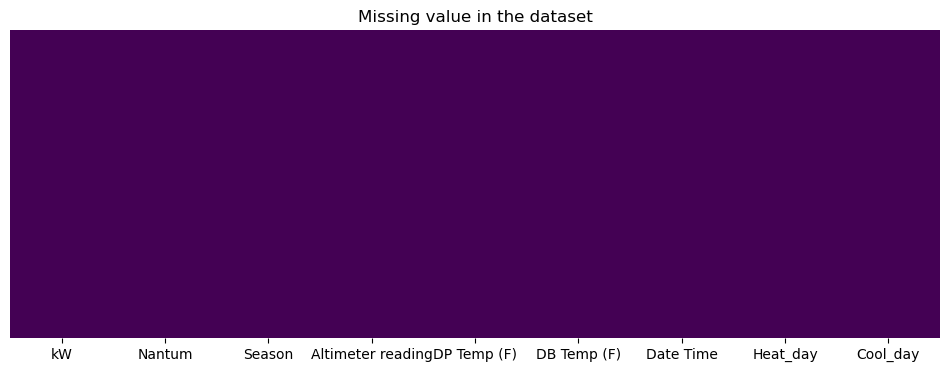

In [255]:
df['Nantum'] = df['Nantum'].replace(' -   ',0, regex=True)
df['Nantum'] = df['Nantum'].replace('Enable',1, regex=True)
df['Nantum'] = df['Nantum'].replace('Disable',0, regex=True)
df['Season'] = df['Season'].replace('Summer',1, regex=True)
df['Season'] = df['Season'].replace('Winter',0, regex=True)

df['DP Temp (F)'] = df['DP Temp (F)'].replace(' - ',0, regex=True)
#df['DP Temp (F)'].fillna(0, inplace=True)


plt.figure(figsize=(12,4))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis',yticklabels=False)
plt.title('Missing value in the dataset')


display(df)

In [256]:
# Add 12 hour previous temps
shift_list = [12]
for i in shift_list:
    df[f'DP_{str(i)}h'] = df['DP Temp (F)'].shift(periods=4*i,fill_value=None)  # dp
    df[f'DB_{str(i)}h'] = df['DB Temp (F)'].shift(periods=4*i,fill_value=None)  # db  

# Add 24 hour previous temps
shift_list = [24]
for i in shift_list:
    df[f'DP_{str(i)}h'] = df['DP Temp (F)'].shift(periods=4*i,fill_value=None)  # dp
    df[f'DB_{str(i)}h'] = df['DB Temp (F)'].shift(periods=4*i,fill_value=None)  # db
  


display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Date Time,Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h
0,161.100,0,0,30.27,24.00,61,3/23/2022 0:00,0.041667,0.041667,None,NaN,None,NaN
1,162.000,0,0,30.27,24.00,61,3/23/2022 0:15,0.041667,0.041667,None,NaN,None,NaN
2,156.600,0,0,30.27,24.00,61,3/23/2022 0:30,0.041667,0.041667,None,NaN,None,NaN
3,161.552,0,0,30.27,24.00,61,3/23/2022 0:45,0.041667,0.041667,None,NaN,None,NaN
4,159.752,0,0,30.26,23.00,58,3/23/2022 1:00,0.072917,0.010417,None,NaN,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35034,117.448,1,0,30.03,34.0,49,3/22/2023 22:45,0.166667,0.000000,26.0,57.0,38.0,46.0
35035,115.200,1,0,30.03,34.0,50,3/22/2023 23:00,0.156250,0.000000,24.0,57.0,38.0,45.0
35036,118.348,1,0,30.03,34.0,50,3/22/2023 23:15,0.156250,0.000000,24.0,57.0,38.0,45.0
35037,116.100,1,0,30.03,34.0,50,3/22/2023 23:30,0.156250,0.000000,24.0,57.0,38.0,45.0


In [257]:
# Code to Merge Date and Time Columns
# df.insert(0, 'Date_Time', pd.to_datetime(df['Date'] + ' ' + df['Time']))
# df.drop(columns=['Date', 'Time'] , inplace=True)


df.insert(0, 'Date Time', df.pop('Date Time'))
df.set_index('Date Time', inplace=True)

# drop the first day because we don't have previous 24h temperatures
df = df.dropna(subset=['DB_24h'])

df.index = pd.to_datetime(df.index)

df['weekday'] = df.index.weekday

# Create a column for whether weekend or weekday: 1 = weekday
df.loc[df['weekday'] > 4, 'Weekend'] = '1'

df['Weekend'] = df['Weekend'].fillna(0)


display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,weekday,Weekend
Date Time,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.00,58,0.072917,0.010417,14.00,72.0,24.00,61.0,3,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.00,58,0.072917,0.010417,14.00,72.0,24.00,61.0,3,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.00,58,0.072917,0.010417,14.00,72.0,24.00,61.0,3,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.00,58,0.072917,0.010417,14.00,72.0,24.00,61.0,3,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.00,56,0.093750,0.000000,12.00,74.0,23.00,58.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,2,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,2,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,2,0


Divide the Weekday into 7 categorical values

In [258]:
from sklearn.preprocessing import OneHotEncoder

# Initialize OneHotEncoder
encoder = OneHotEncoder()

# Fit and transform the weekday column
weekday_encoded = encoder.fit_transform(df[['weekday']])

# Convert the encoded result to a DataFrame
weekday_encoded_df = pd.DataFrame(weekday_encoded.toarray(), columns=encoder.categories_[0])

# change encoded values to int from float
weekday_encoded_df = weekday_encoded_df.astype(int)

# add a string to each column name for clarification
weekday_encoded_df.columns = ['Weekday_' + str(col) for col in weekday_encoded_df.columns]

display(weekday_encoded_df)

# change the indexing to integer to merge two datasets
df.reset_index(drop=False, inplace=True)

# merge the columns
for column in weekday_encoded_df.columns:
    column_name_str = str(column)

    df = df.join(weekday_encoded_df[column], rsuffix= 'Weekday: ' + column_name_str)

# set index back to date time
df.set_index('Date Time', inplace=True)


# Drop the weekday column
df.drop(columns=['weekday'], inplace=True)

display(df)    



,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
0,0,0,0,1,0,0,0
1,0,0,0,1,0,0,0
2,0,0,0,1,0,0,0
3,0,0,0,1,0,0,0
4,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...
34938,0,0,1,0,0,0,0
34939,0,0,1,0,0,0,0
34940,0,0,1,0,0,0,0
34941,0,0,1,0,0,0,0


,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekend,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.00,58,0.072917,0.010417,14.00,72.0,24.00,61.0,0,0,0,0,1,0,0,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.00,58,0.072917,0.010417,14.00,72.0,24.00,61.0,0,0,0,0,1,0,0,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.00,58,0.072917,0.010417,14.00,72.0,24.00,61.0,0,0,0,0,1,0,0,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.00,58,0.072917,0.010417,14.00,72.0,24.00,61.0,0,0,0,0,1,0,0,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.00,56,0.093750,0.000000,12.00,74.0,23.00,58.0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,0,0,0,1,0,0,0,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,0,1,0,0,0,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,0,1,0,0,0,0


In [259]:
# Export to Excel file
df.to_excel('preprocessed_combined_data_3-2022_3-2023.xlsx', index=True)
df.to_csv('preprocessed_combined_data_3-2022_3-2023.csv', index=True)


PREPROCESSING IS DONE